### *NSE 351 - Spring 2026*
# **Final Project: Exploring the Design of a Cylindrical Pebble Bed Reactor**

#### Nathan Carpenter

In this project, I have built a tool that can be used to perform two-group diffusion calculations of a cylindrical pebbel bed reactor. This reactor is uniform radially, but has different regions with different material compositions axially.

I worked on the code with Kyle Skuta and Hunter Memphis, Kyle did the hand calculation to verify the code was functioning correctly in part 1. The majority of the code was written primarily by me.

This report was not made in collaboration with Kyle or Hunter, though we had a shared github repository to work on code together, so they could see it.


# **Part 1: Two-group diffusion solver**

The project requires solving the two-group slab geometry diffusion equations:

**Fast Group:**
$$-\frac{\partial}{\partial z}\left(D_1(z) \frac{\partial \phi_1}{\partial z}\right) + \Sigma_{r,1}(z)\phi_1 = \frac{1}{k} S_f(z)$$
**Thermal Group:**
$$-\frac{\partial}{\partial z}\left(D_2(z) \frac{\partial \phi_2}{\partial z}\right) + \Sigma_{a,2}(z)\phi_2 = \Sigma_{s,1\rightarrow2}(z)\phi_1$$



In [2]:
# Importing necessary libraries

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
from scipy.special import j0, j1 # Bessel functions of the first kind for part 2

### **expand_regions:**

the regions are defined in large chunks, and then sliced up into uniform cells, taking the specifications inputted and splitting up the regions into different array type outputs full of cells to be used in the loss matrix.

In [3]:
def expand_regions(regions):
    D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx, = [], [], [], [], [], [], [], []

    for reg in regions:
        Nc = reg['Nc']
        D1.extend([reg['D1']] * Nc)
        D2.extend([reg['D2']] * Nc)
        Sa1.extend([reg['Sa1']] * Nc)
        Sa2.extend([reg['Sa2']] * Nc)
        Ss12.extend([reg['Ss12']] * Nc)
        nSf1.extend([reg['nSf1']] * Nc)
        nSf2.extend([reg['nSf2']] * Nc)
        dx.extend([reg['dx']] * Nc)
    
    D1 = np.array(D1, dtype=float)
    D2 = np.array(D2, dtype=float)
    Sa1 = np.array(Sa1, dtype=float)
    Sa2 = np.array(Sa2, dtype=float)
    Ss12 = np.array(Ss12, dtype=float)
    nSf1 = np.array(nSf1, dtype=float)
    nSf2 = np.array(nSf2, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx

### **build_loss_matrix:**

The continuous diffusion equation needs to be turned into a matrix so that the computer can solve alegraic equations

Boundary conditions had to be modified from the One-group code, because the sides are symmetrical. The project says *"Allow the boundary conditions to be either reflecting or zero incident partial current at the top and bottom of the reactor"*. Initially, I decided to use zero incident partial current. However, after getting high PPF values, I thought that a reflecting boundary would make this better, as it would keep more neutrons inside at the edges. Since I had the vaccum code initially, I made either possible by selecting the boundary type when calling the function. So the two methods could be compared

In [4]:
def build_loss_matrix(D, Sig_r, dx, bc_type="reflecting"):
    """
    Builds tridiagonal matrix for a 1D diffusion system.
    Applies either 'reflecting' or 'vacuum' (zero incident partial current)
    boundary conditions at both the top and the bottom of the reactor.
    """
    N = len(D)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)

    # Interior interface conductances
    F = np.zeros(N - 1) # F array ensures leakage is conserved across interfaces
    for i in range(N - 1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])

    for i in range(N):
        diag[i] += Sig_r[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N - 1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Apply external boundary conditions based on selected type
    if bc_type == "vacuum":
        # Left Boundary Condition (zero incident partial current)
        beta_left = 2.0 * D[0] / dx[0]
        alpha_left = beta_left / (2.0 * beta_left + 1.0)
        diag[0] += alpha_left

        # Right Boundary Condition (zero incident partial current)
        beta_right = 2.0 * D[-1] / dx[-1]
        alpha_right = beta_right / (2.0 * beta_right + 1.0)
        diag[-1] += alpha_right
        
    elif bc_type == "reflecting":
        # Net current J = 0 at outer edges. No additional boundary leakage 
        pass

    A = diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return A


### **solve_two_group_k_eigenvalue:**

The bulk of this code is repurposed form the one group solver given to the class. 

First, the removal cross sections are defined. Fast neutrons are either being removed by being absorbed ($\Sigma_{a,1}$) or by scattering down into the thermal group ($\Sigma_{s,1\rightarrow2}$). Thermal neutrons are being removed soley by absorption ($\Sigma_{a,2}$)

Then, the loop. I dont know k or the flux shape, so the code must guess and iterate. It first assumes k = 1.0 and a flat flux shape to make a fission source base. It then divides that by k, and uses spsolve to find the new fast flux ($\phi_1$). The thermal neutron source is scattering, not fission, so the fast flux is multiplied by the scattering cross section ($\Sigma_{s,1\rightarrow2}$) and is used as to solve the thermal flux ($\phi_2$). It then updates k by calculating the new source with the two fluxes by looking at the ratio of the new source to the old source, and check for convergence. 

In [5]:
def solve_two_group_k_eigenvalue(
    regions,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections
    Sr1 = Sa1 + Ss12   # Fast removal: Absorption + Scattering
    Sr2 = Sa2          # Thermal removal: Absorption

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)

    for iteration in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)

        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

### **make_region:**

This creates a region in the reactor, isolated so that I can easily create each zone and move them around while testing. 

In [6]:
def make_region(fuel_dict, length_cm, num_cells, label):
    reg = fuel_dict.copy()
    reg['Nc'] = num_cells
    reg['dx'] = length_cm / num_cells
    reg['label'] = label
    return reg

### **plot_reactor_results:**

This function plots the results of the solver. It outputs two graphs, one of flux profiles together and another of the normalized power distribution. It was isolated into its own function so that I could test several different core layouts at the same time and compare their results. It combines the core layout graph into the other two graphs, so that the influence of each fuel type on the graphs were clearer to see.

In [7]:
def plot_reactor_results(x, phi1, phi2, normalized_power, given_core_layout):
    """
    Function built to plot the results of the two-group diffusion solver.
    This is needed so that I can test various different core layouts and compare them in terms of Keff and PPF
    """
    # Plotting results
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

    # Plot 1: Flux Profiles
    ax1.plot(x, phi1, label=r'Fast Flux ($\phi_1$)', color='blue', linewidth=2)
    ax1.plot(x, phi2, label=r'Thermal Flux ($\phi_2$)', color='red', linewidth=2)
    ax1.set_ylabel("Relative Flux")
    ax1.set_title("Axial Fast and Thermal Flux Shapes")
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Color pallete for different fuel types
    default_colors = {
        "Fresh": "#d4f1f9", 
        "Once-Burned": "#f9ebd4", 
        "Twice-Burned": "#f9d4d4",
        "Reflector": "#e2e2e2"
    }

    # apply background color spans and text labels
    current_x = 0
    for reg in given_core_layout:
        reg_length = reg["dx"] * reg["Nc"]
        label = reg.get("label", "Unknown")
        bg_color = default_colors.get(label, "#f0f0f0") # Fallback to light grey
        
        # background shading
        ax1.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        ax2.axvspan(current_x, current_x + reg_length, color=bg_color, alpha=0.4)
        
        # label text at the top of the bottom plot
        ax2.text(current_x + reg_length/2, 1.02, label, 
                 ha='center', va='bottom', fontsize=9, rotation=0)
        
        current_x += reg_length

    # Plot 2: Normalized Power Distribution
    ax2.plot(x, normalized_power, label="Normalized Power", color='purple', linewidth=2)
    ax2.axhline(1.0, color='black', linestyle='--', label="Average Power", alpha=0.5)
    
    ax2.set_xlabel("Axial Position (cm)")
    ax2.set_ylabel(r"Normalized Power ($P/P_{ave}$)")
    ax2.set_title("Axial Power Distribution")
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()
    

### **output_results:**

For the sake of smoother testing, I isolated the code for executing the calculations and print statements at the very end. It allowed me to easily test several different core layouts at the same time with less code.

the peaking factor is calculated and the power is normalized

In [8]:
def output_results(x, phi1, phi2, k, nSf1, nSf2, output_core_layout):
    # Calculate Power & Peaking
    power_distribution = nSf1 * phi1 + nSf2 * phi2
    p_ave = np.mean(power_distribution)
    p_max = np.max(power_distribution)
    peaking_factor = p_max / p_ave
    normalized_power = power_distribution / p_ave

    print(f"--- Core Calculation Results ---")
    print(f"k-effective: {k:.5f}")
    print(f"Power Peaking Factor: {peaking_factor:.5f}")
    print(f"Target met? k > 1.05: {k > 1.05}, PPF: < 1.15: {peaking_factor < 1.15}")

    plot_reactor_results(x, phi1, phi2, normalized_power, output_core_layout)


### **Hand Calculation Verification**
The code is verified by solving a problem with homogenous material properties and comparing the result with a hand-calculated multiplication factor ($k_\infty$ and $k$) using the six-factor formula

$$\Sigma_{a2}\phi_2=\Sigma_{s,1\rightarrow2}\phi_1$$
$$\frac{\phi_2}{\phi_1}=\frac{\Sigma_{s,1\rightarrow2}(z)\phi_1}{\Sigma_{a2}}=\frac{0.0068}{0.0105}=0.6476$$
$$\rho=\nu\Sigma_{f1}\phi_1+\nu\Sigma_{f2}\phi_2=0.0035\phi_1+0.0145(0.6476)\phi_1=0.00974\phi_1$$
$$L=\phi_1\left(\Sigma_{a1}+\Sigma_{s,1\rightarrow2}\right)=\phi_1\left(0.0012+0.0068\right)=0.00800\phi_1$$
$$k_\infty=\frac{\rho}{L}=\frac{0.00974\phi_1}{0.00800\phi_1}=1.217$$

In [9]:
# Fuel properties given in Table 1
fresh = {"D1": 1.55, "D2": 0.82, "Sa1": 0.0012, "Sa2": 0.0105, "Ss12": 0.0068, "nSf1": 0.00035, "nSf2": 0.0145}
once  = {"D1": 1.50, "D2": 0.80, "Sa1": 0.0016, "Sa2": 0.0125, "Ss12": 0.0065, "nSf1": 0.00045, "nSf2": 0.0132}
twice = {"D1": 1.45, "D2": 0.78, "Sa1": 0.0021, "Sa2": 0.0155, "Ss12": 0.0062, "nSf1": 0.00055, "nSf2": 0.0115}

hand_calc_k = 1.217

verification_core = [
    make_region(fresh, 600, 300, "Fresh")
]

x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(
    verification_core,
    bc_type="reflecting"
)

print("--- Code Verification Results ---")
print(f"Numerical k = {k:.5f}")
print(f"Hand-calculated k = {hand_calc_k:.3f}")
print(f"The numerical and hand-calculated k values are the same to 2 decimal places: {round(k, 2) == round(hand_calc_k, 2)}")

--- Code Verification Results ---
Numerical k = 1.21756
Hand-calculated k = 1.217
The numerical and hand-calculated k values are the same to 2 decimal places: True


### **Execution of code for part 1 of project**

This is where I defined the properties given, define my core layout, and execute the solver and plotter.
I tested many different core layouts, with this being the best one I tested. The keff is solidly above benchmark, and the PPF is as low as I have gotten it while maintaining the keff.


Each fuel type has 200 cm total. The middle is filled with the twice-burned fuel, with the sides both having a symmetric fresh fuel section with a once-burned border. 

--- Core Calculation Results ---
k-effective: 1.10878
Power Peaking Factor: 2.59705
Target met? k > 1.05: True, PPF: < 1.15: False


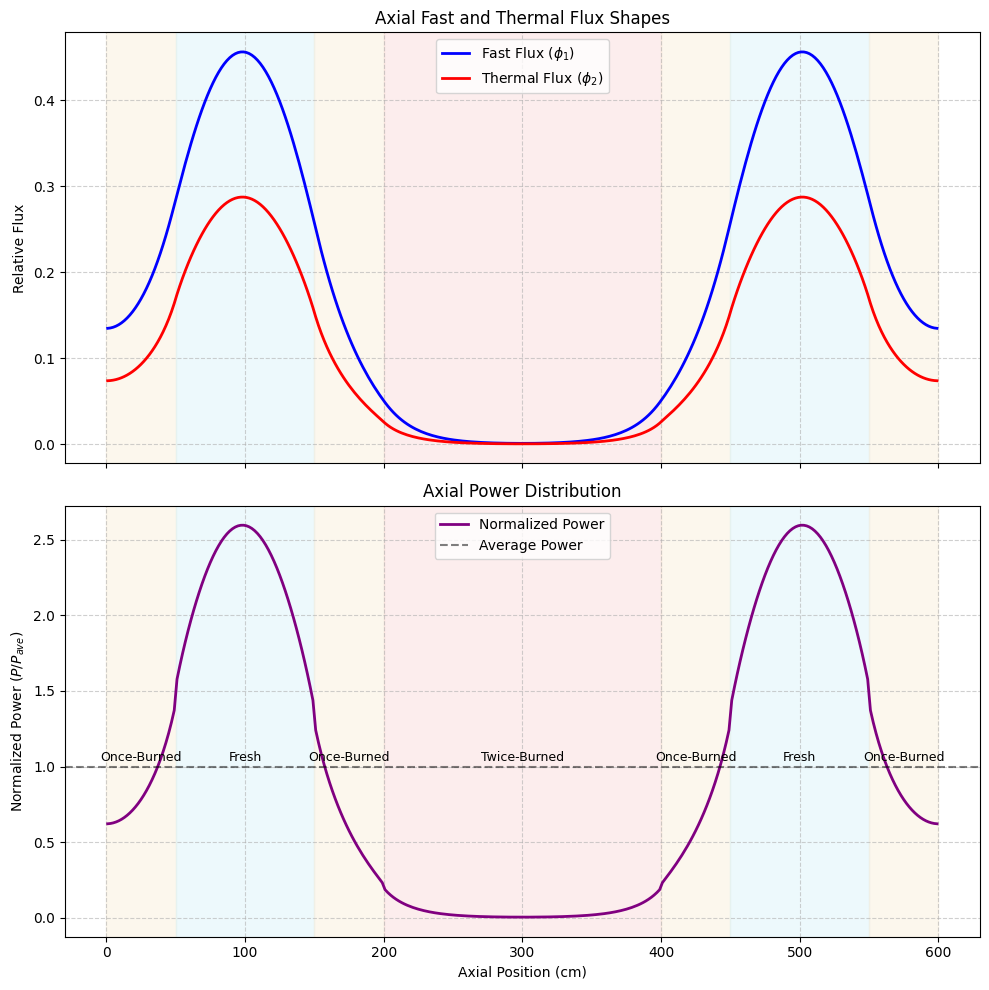

In [10]:
# Chosen core layout based on testing
core_layout_1 = [

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(twice,  200, 100, "Twice-Burned"),

    make_region(once,  50, 25, "Once-Burned"),

    make_region(fresh,  100, 50, "Fresh"),
    
    make_region(once,  50, 25, "Once-Burned"),
]


x, phi1, phi2, k, nSf1, nSf2 = solve_two_group_k_eigenvalue(core_layout_1, bc_type="reflecting")
output_results(x, phi1, phi2, k, nSf1, nSf2, core_layout_1)


### **Discussion of Part 1 results**

The goal of this simulation is to maximize the multiplication factor $k$ ($> 1.05$) while minimizing power peaking ($P_{max}/P_{ave} < 1.15$). This is a tradeoff. 

Fresh fuel has the highest reactivity. If it is put in the center of the reactor, $k$ will be incredibly high, but there will be a massive flux peak in the center. Putting all of the Fresh fuel at the edges with a reflecting boundary does lower the $PPF$ some, and if the boundary is a vacuum the $PPF$ will lower further, as more neutrons can escape. The $PPF$ is still over 3 in this case, though.

From there, I did further testing. When Fresh fuel was on the interior, but the middle was filled with twice-burned fuel and the edges had once-burned fuel, I got a yet lower $PPF$. At this point, I went back to my boundary code and changed from a vacuum to a reflector. Intially, I thought that fresh fuel at the edge with a vacuum would help to lower the peak by draining neutrons, but after testing that didn't work as well as a reflector with fuel in the arrangement. I tested many different layouts, both with reflecting and vacuum boundaries. During my tests, I was able to get a $PPF$ of below 1.15, but not while keeping $k$ above 1.05, which I deemed more important. If $PPF$ is too high, the fuel gets too hot, and can have problems. If $k$ gets too low, the reactor stops working altogether.  

The layout above, Once-Fresh-Once-Twice-Once-Fresh-Once with a reflecting top and bottom boundary, had the lowest $PPF$ while maintaining an acceptable $k$.


# **Part 2: Extensions of the core design**
## **Part 2.1: Modeling a 2D cylindrical reactor**

Modifying the 1D axial code to model a 2D cylindrical core, with the assumption that the core is radially homogenous in each axial region. So, the two-group fluxes obey the following equations in each axial region:
<br><br>

\begin{align}
&-\frac{D_1(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial \phi_1(r, z)}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_1(z) \frac{\partial \phi_1(r, z)}{\partial z} \right) \nonumber \\
&+\Sigma_{r,1}(z)\phi_1(r, z) = \frac{1}{k} \left( \nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z) \right) \tag{3} \\[10pt]
&-\frac{D_2(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial \phi_2(r, z)}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_2(z) \frac{\partial \phi_2(r, z)}{\partial z} \right) \nonumber \\
&+\Sigma_{a,2}(z)\phi_2(r, z) = \Sigma_{s,1\to2}(z)\phi_1(r, z) \tag{4}
\end{align}

<br><br>
To simplify this, I assume that the flux $\phi(r,z)$ is a separable function of $r$ and $z$: $\phi(r,z)=\Psi(r)\Phi(z)$, and substitute this in to the 2D diffusion equations
<br><br><br>
This is rearranged to obtain the form of $F(r) = G(z)$, and the only way this equation is true for all $r$ and $z$ is if $F(r) = G(z) =$ constant.
<br><br><br>



### **Separating and rearranging equations:**

Plugging in our substitution, I get:

$$- \frac{D_1(z)}{r} \frac{\partial}{\partial r} \left( r \frac{\partial [\Psi(r)\Phi_1(z)]}{\partial r} \right) - \frac{\partial}{\partial z} \left( D_1(z) \frac{\partial [\Psi(r)\Phi_1(z)]}{\partial z} \right) + \Sigma_{r,1}(z)[\Psi(r)\Phi_1(z)] = \frac{1}{k} \left( \nu\Sigma_{f,1}(z)[\Psi(r)\Phi_1(z)] + \nu\Sigma_{f,2}(z)[\Psi(r)\Phi_2(z)] \right)$$

Partial derivateves with respect to $r$ will treat $z$-dependent terms as constants and vice versa, so I can pull out terms:

$$- D_1(z) \Phi_1(z) \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] - \Psi(r) \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] + \Sigma_{r,1}(z)\Psi(r)\Phi_1(z) = \frac{\Psi(r)}{k} \left( \nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z) \right)$$

Now, I can divide both sides by $\phi(r,z)=\Psi(r)\Phi(z)$ to get:

$$- \frac{D_1(z)}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] - \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] + \Sigma_{r,1}(z) = \frac{1}{k} \left( \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right)$$

Then, I move all other terms than the $r$ dependent piece to the right of the equals sign, and divide by $D_1(z)$ to get an equation where the left side is a function of $r$, and the right as a function of $z$:

$$-\frac{1}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] = \frac{1}{D_1(z)} \left( \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] - \Sigma_{r,1}(z) + \frac{1}{k} \left[ \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right] \right)$$

Like said before, since each side is independent, I could hold $z$ the same while changing $r$, and the equation would have to stay equal, so both sides must be equal to a constant. To focus on the $r$ side, with our constant being the radial geometric buckling $B_r^2$:

$$-\frac{1}{\Psi(r)} \left[ \frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) \right] = B_r^2$$

Rearranging this, I can get the equation into this format:

$$\frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) + B_r^2 \Psi(r) = 0$$

Now, focusing on the $z$ side of the equation, setting it equal to $B_r^2$:
$$\frac{1}{D_1(z)} \left( \frac{1}{\Phi_1(z)} \left[ \frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) \right] - \Sigma_{r,1}(z) + \frac{1}{k} \left[ \frac{\nu\Sigma_{f,1}(z)\Phi_1(z) + \nu\Sigma_{f,2}(z)\Phi_2(z)}{\Phi_1(z)} \right] \right) = B_r^2$$

Multiplying both sides by $D_1(z)\Psi_1(z)$ to clear the fractions and rearranging:
$$-\frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) + \left[ \Sigma_{r,1}(z) + D_1(z)B_r^2 \right] \Phi_1(z) = \frac{1}{k}\left( \nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z) \right)$$

$\nu\Sigma_{f,1}(z)\phi_1(r, z) + \nu\Sigma_{f,2}(z)\phi_2(r, z)$ is simply written as $S_f(z)$ like in our 1D equations from part 1: 

$$-\frac{d}{d z} \left( D_1(z) \frac{d \Phi_1(z)}{d z} \right) + \left[ \Sigma_{r,1}(z) + D_1(z)B_r^2 \right] \Phi_1(z) = \frac{1}{k} S_f(z)$$

This form is identical to our fast group equation from the 1D equations, except the physical removal cross section has another term to it: 

$$-\frac{\partial}{\partial z}\left(D_1(z) \frac{\partial \phi_1}{\partial z}\right) + \Sigma_{r,1}(z)\phi_1 = \frac{1}{k} S_f(z)$$

So from this, our new leakage cross section is now:

$$\Sigma_{r,1, \text{new}}(z) = \Sigma_{r,1}(z) + D_1(z) B_r^2$$

Which accounts for the fact that neutrons are now escaping horizontally out of the cylinder's radial boundaries



### **Summary and recap:**
- I plug $\phi(r,z)=\Psi(r)\Phi(z)$ into the 2D equations and rearranging into a format fitting $F(r) = G(z) = B_r^2$

- Isolating and rearranging both sides further, I get the two following equations:
$$\frac{1}{r} \frac{d}{d r} \left( r \frac{d \Psi(r)}{d r} \right) + B_r^2 \Psi(r) = 0$$
$$\Sigma_{r,1, \text{new}}(z) = \Sigma_{r,1}(z) + D_1(z) B_r^2$$

### **Zero-order Bessel differential equation:**

The first equation we got is a zero-order Bessel differential equation. It is a second-order differential equation, so its general solution muust contain two independent functions and two constants of integration:

$$\Psi(r)=AJ_0(B_rr)+CY_0(B_rr)$$

$J_0$ here is the Bessel function of the first kind of order zero. $Y_0$ is the Bessel function of the second kind of order zero.

At $r=0$ in the core of the reactor, $J_0()=1$, which is a perfectly fine and finite answer, but as $r$ approaches 0, $Y_0(B_rr)=-\infty$, which is not physically possible. This means $C$ must be equal to 0 for the equation to remain finite, so our equation simplifies further to:

$$\Psi(r)=AJ_0(B_rr)$$

Applying the other boundary contition at the outer edge, if I assume it will be a vacuum the neutron flux will drop to zero.

$$J_0(B_rR)=0$$

Thsi means $J_0$ is zero with this value. Looking at the Bessel function roots, the first is at $J_0(2.4048)=0$, and the reactor's flux cannot be negative so this is the only root we care about. This means that $B_rR=2.4048$. We know that the radius of our reactor is 4m or 400cm. Thus, I can find the radial buckling:

$$B_r^2=\left(\frac{2.40483}{400 \text{ cm}}\right) = 0.000036145 \text{ cm}^{-2}$$


### **solve_2d_cylindrical_eigenvalue:**

Modified 2D two-group core solver. It has updated axial equations, adding the new $D_1(z)B_r^2$ factor to both fast and thermal removal cross sections. Now that we are looking in 2D, neutrons will leak radially out of the cylinder, and this reflects the change.

In [11]:
def solve_2d_cylindrical_eigenvalue(
    regions,
    Br2,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500,
    bc_type="reflecting"
):
    x, D1, D2, Sa1, Sa2, Ss12, nSf1, nSf2, dx = expand_regions(regions)
    N = len(x)

    # Removal cross sections, modified to include new radial leakage term (D * Br^2)
    Sr1 = Sa1 + Ss12 + (D1 * Br2)   # Fast removal: Absorption + Scattering + Radial Leakage
    Sr2 = Sa2 + (D2 * Br2)          # Thermal removal: Absorption + Radial Leakage

    # Building the loss matrices for both groups using the specified BC
    A1 = build_loss_matrix(D1, Sr1, dx, bc_type=bc_type)
    A2 = build_loss_matrix(D2, Sr2, dx, bc_type=bc_type)

    k = 1.0
    phi1 = np.ones(N)
    phi2 = np.ones(N)

    # Initial fission source
    fission_source = (nSf1 * phi1 + nSf2 * phi2) * dx
    fission_source /= np.sum(fission_source)


    for it in range(1, max_iters + 1):
        # Step 1: Solving fast group
        rhs1 = fission_source / k
        phi1_new = spsolve(A1, rhs1)

        # Step 2: Solving thermal group (source is from scattering from fast group)
        rhs2 = Ss12 * phi1_new * dx
        phi2_new = spsolve(A2, rhs2)

        # Step 3: Calculating new fission source
        fission_source_raw = (nSf1 * phi1_new + nSf2 * phi2_new) * dx
        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        # Step 4: Normalizing fluxes
        normalization_factor = np.sum(fission_source_raw)
        phi1_new /= normalization_factor
        phi2_new /= normalization_factor
        fission_source_new = fission_source_raw / normalization_factor

        # Step 5: Checking for convergence
        k_error = abs(k_new - k) / abs(k)
        source_error = np.linalg.norm(fission_source_new - fission_source, ord=np.inf) / np.linalg.norm(fission_source, ord=np.inf)


        if k_error < k_tol and source_error < source_tol:
            return x, phi1_new, phi2_new, k_new, nSf1, nSf2
        
        k = k_new
        phi1 = phi1_new
        phi2 = phi2_new
        fission_source = fission_source_new
    
    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi1_new, phi2_new, k_new, nSf1, nSf2

### **Execution of code for part 2.1 of project**

This defines variables that are given and calculates the radial buckling calculated by hand above. It also combines the axial power distribution and radial power shape into a full 2D grid matrix. It visually maps power density throughout the entire reactor core using a 2D mesh.

Radial Buckling (Br^2): 3.614505e-05 cm^-2
 
--- 2D Cylindrical Reactor Results ---
2D k-effective: 1.09853
2D Power Peaking Factor: 6.01852


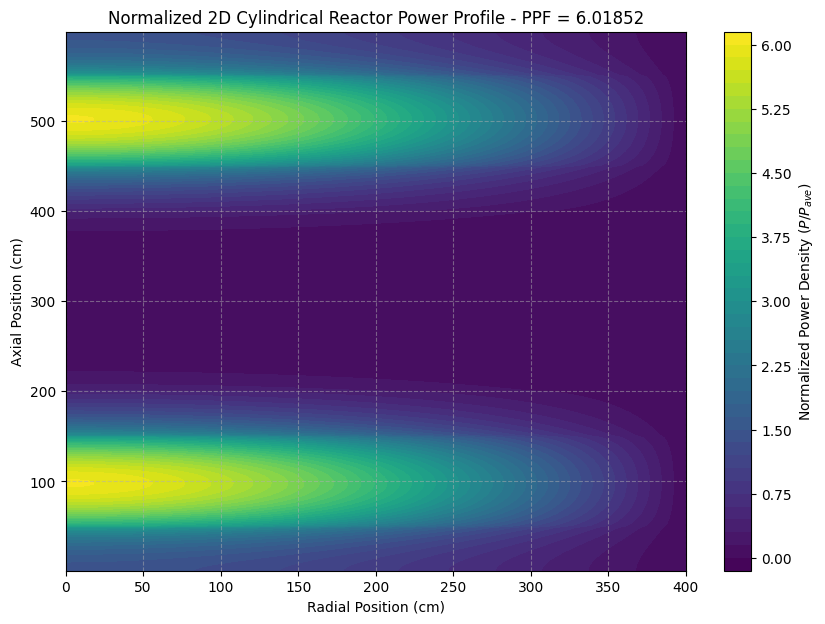

In [ ]:
# Core dimensions:
R_core = 400.0 #cm, or 4 meters tall
H_core = 600.0 #cm, or 6 meters tall

# Calculate constant radial buckling:
bessel_zero = 2.40483
Br = bessel_zero / R_core
Br2 = Br**2

print(f"Radial Buckling (Br^2): {Br2:.6e} cm^-2")

# Define radial grid for plotting and analysis
num_r_points = 50
r_grid = np.linspace(0, R_core, num_r_points)

# Analytical radial flux shape normalized to an average value of 1.0
# The average of J0(Br*r) over the cross-section is (2 * J1(Br*R)) / (Br*R)
radial_avg_j0 = (2.0 * j1(bessel_zero)) / bessel_zero
radial_power_shape = j0(Br * r_grid) / radial_avg_j0

# Executing code using fuel layout from Section 1
x_centers, phi1_2d, phi2_2d, k_2d, nSf1_arr, nSf2_arr = solve_2d_cylindrical_eigenvalue(core_layout_1, Br2, bc_type="reflecting")

# Calculate normalized axial power distribution
axial_power = nSf1_arr * phi1_2d + nSf2_arr * phi2_2d
axial_power_norm = axial_power / np.mean(axial_power)

# Use Meshgrid to superimpose profiles across 2D space
R_mesh, Z_mesh = np.meshgrid(r_grid, x_centers)
P_mesh = np.zeros_like(R_mesh)

for i in range(len(x_centers)):
    P_mesh[i, :] = axial_power_norm[i] * radial_power_shape

# Calculate final power peaking factor for the assembly
ppf_2d = np.max(P_mesh) / 1.0 # Normalized average is 1.0
print(" ")
print(f"--- 2D Cylindrical Reactor Results ---")
print(f"2D k-effective: {k_2d:.5f}")
print(f"2D Power Peaking Factor: {ppf_2d:.5f}")

# Render the Plot
plt.figure(figsize=(10, 7))
contour = plt.contourf(R_mesh, Z_mesh, P_mesh, 50, cmap='viridis')
plt.colorbar(contour, label=r"Normalized Power Density ($P / P_{ave}$)")
plt.title(f"Normalized 2D Cylindrical Reactor Power Profile - PPF = {ppf_2d:.5f}")
plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **Discussion of Part 2.1 results**

The K-effective of the 2D simulation is still healthily above the 1.05 benchmark needed. The 2D power peaking factor, however, is much higher than 1D at 6.01852. The most ideal result of $PPF$ I could achieve in the 1D simulation was that of 2.59705. Since $PPF_{\text{total}} = PPF_{\text{radial}} \times PPF_{\text{axial}}$, this means my radial power peaking factor was 2.31744.

The 1D simulation, when being used to simulate this reactor, assumes that the radial plane is infinite and flat, with a $PPF_{\text{radial}} = 1$ where neutrons only can leak out of the top and bottom. In a real 3D unreflected cylinder, the severe leakage massively increases the total $PPF$, even with the top and bottom reflecting perfectly. 

A real 3D reactor cannot be unreflected radially. Treating the boundary with an albedo that reflects some of the outgoing neutrons back into the reactor would lower the $PPF_{\text{radial}}$ and start to bring the total power peaking factor back towards the radial only. 

## **Part 2.2: Pebble temperature distributions**

I am now calculating the radial temperature distribution inside an individual fuel pebble at any point $(r,z)$ in the core, assuming the core average power is 200 MWth. These fuel pebbles are composed of an inner fuel ball (radius $r_f$) with graphite coating (thickness $t_c$). 

Core volume = 301.593 m^3
Average power density = 6.631e+05 W/m^3

Maximum centerline temperature = 936.96 K
Minimum centerline temperature = 900.00 K

Hottest location:
r = 0.00 cm
z = 99.00 cm


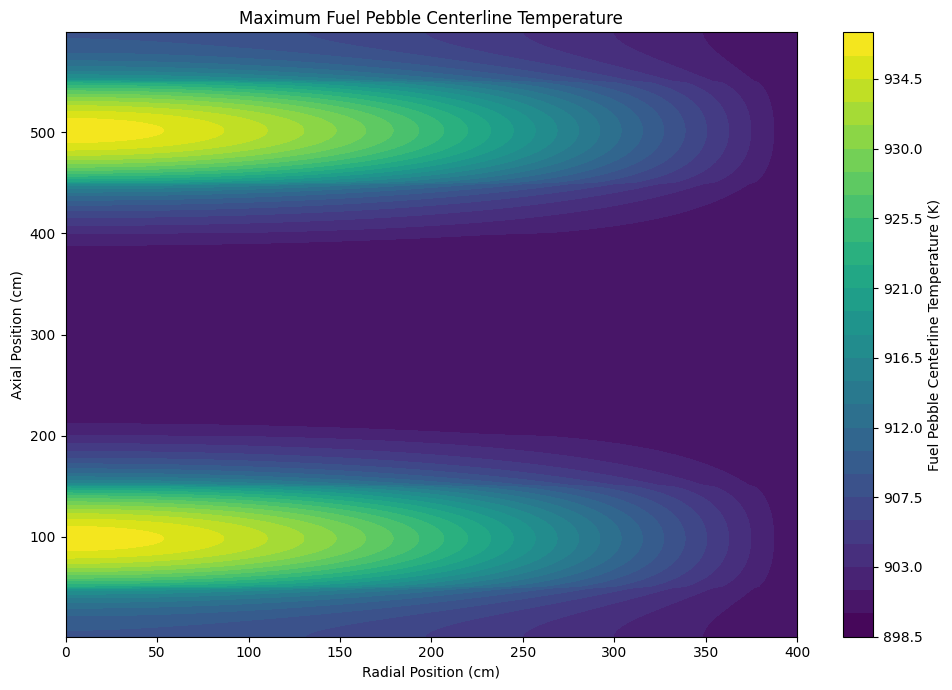

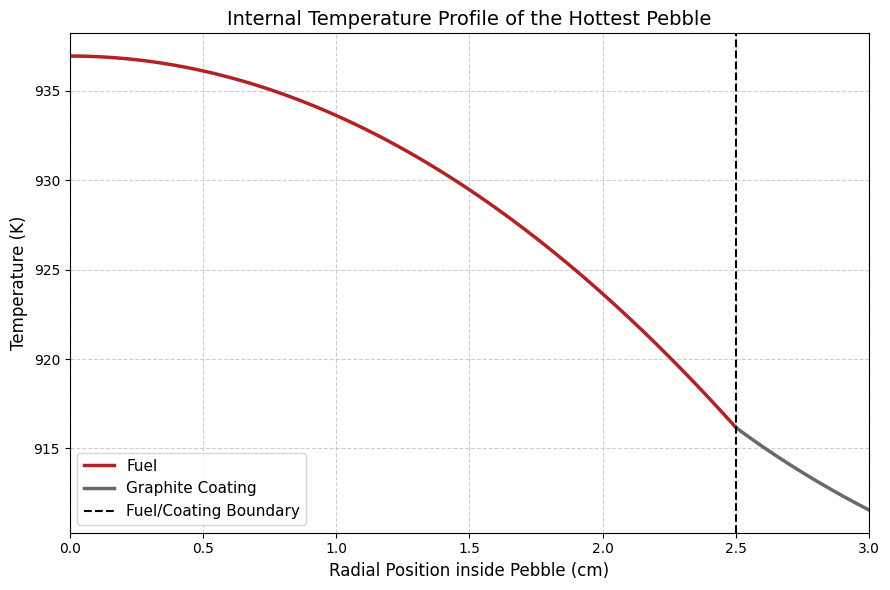

In [ ]:
# Thermal parameters from Table 2
T_cool = 900.0 # K
rf = 0.025 # m
tc = 0.005 # m
ro = rf + tc # m
kf = 20.0 # W/m-K
kc = 30.0 # W/m-K
h = 2000.0 # W/m^2-K

# Core geometry
R_core = 4.0 # m
H_core = 6.0 # m
P_core = 200e6 # W

# Average volumetric power density
V_core = np.pi * R_core**2 * H_core
q_avg = P_core / V_core

print(f"Core volume = {V_core:.3f} m^3")
print(f"Average power density = {q_avg:.3e} W/m^3")

# Local power density
q_local = q_avg * P_mesh

# Temperature rise components
Q_pebble = q_local * (4/3) * np.pi * rf**3 # heat leaving one pebble
A_pebble = 4 * np.pi * ro**2 # pebble surface area
dT_conv = Q_pebble / (h * A_pebble) # convection rise


dT_coating = (q_local * rf**3 / (3 * kc) * (1/rf - 1/ro)) # graphite coating rise
dT_fuel = q_local * rf**2 / (6 * kf) # fuel-center rise

# total centerline temperature
T_center = T_cool + dT_conv + dT_coating + dT_fuel

# Results
print(f"\nMaximum centerline temperature = {np.max(T_center):.2f} K")
print(f"Minimum centerline temperature = {np.min(T_center):.2f} K")

imax = np.unravel_index(np.argmax(T_center), T_center.shape) # location of hottest pebble

print("\nHottest location:")
print(f"r = {R_mesh[imax]:.2f} cm")
print(f"z = {Z_mesh[imax]:.2f} cm")

# Plotting
plt.figure(figsize=(10,7))

cont = plt.contourf(R_mesh, Z_mesh, T_center, levels=30)
plt.colorbar(cont, label="Fuel Pebble Centerline Temperature (K)")

plt.xlabel("Radial Position (cm)")
plt.ylabel("Axial Position (cm)")
plt.title("Maximum Fuel Pebble Centerline Temperature")

plt.tight_layout()
plt.show()

q_max = q_local[imax] 

# 2. Define radial meshes for the two zones (in meters for math, we will plot in cm)
r_fuel = np.linspace(0, rf, 100)
r_coat = np.linspace(rf, ro, 50)

# 3. Calculate temperatures from the outside boundary inward
# Surface temperature (Coolant Temp + Convection Rise)
T_surf = T_cool + (q_max * rf**3) / (3 * h * ro**2)

# Coating temperature profile (Source-free spherical conduction)
T_coat_profile = T_surf + (q_max * rf**3) / (3 * kc) * (1/r_coat - 1/ro)

# Temperature exactly at the fuel/coating interface (r = rf)
T_interface = T_surf + (q_max * rf**3) / (3 * kc) * (1/rf - 1/ro)

# Fuel meat temperature profile (Uniform internal heat generation)
T_fuel_profile = T_interface + q_max / (6 * kf) * (rf**2 - r_fuel**2)

# 4. Plot the profiles
plt.figure(figsize=(9, 6))

# Plot both regions (converting radii from meters to cm for a cleaner x-axis)
plt.plot(r_fuel * 100, T_fuel_profile, color='firebrick', linewidth=2.5, label='Fuel')
plt.plot(r_coat * 100, T_coat_profile, color='dimgray', linewidth=2.5, label='Graphite Coating')

# Add a vertical dashed line to mark the boundary interface
plt.axvline(x=rf * 100, color='black', linestyle='--', linewidth=1.5, label='Fuel/Coating Boundary')

# Formatting
plt.xlabel('Radial Position inside Pebble (cm)', fontsize=12)
plt.ylabel('Temperature (K)', fontsize=12)
plt.title('Internal Temperature Profile of the Hottest Pebble', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xlim(0, ro * 100)

plt.tight_layout()
plt.show()

### **Discussion of Part 2.1 results**

The highest maximum centerline temperatures occur in the Fresh fuel batches, decreasing into the once-burned fuel and the lowest in the twice-burned fuel. It is also the highest in the center of the reactor, decreasing as you move out radially. This is because the fresh fuel has the higest macroscomic fission cross section ($\Sigma_f$) and the lowest absorption cross section compared to once or twice burned fuel, making the fresh regions the primary contributor towards neutron flux. 

The fuel interior has the largest centerline temperature rise, because the fuel interior has a lower thermal conductivity ($k_f$) than the graphite coating. That low thermal conductivity is the main limiting factor for the thermal makeup. The core was designed to create a specific flux shape, and this flux directly controls the heat generation rate.